# Mycosis Fungoides (MF) — Multi-Task Prediction Model
**Tasks:**
1. **Task 1 — Diagnosis:** Predict MF vs Non-MF
2. **Task 2 — Stage of MF:** Predict Patch-Plaque vs Tumor *(MF patients only)*
3. **Task 3 — Visit Type:** Predict New / FU / Rec *(All Patients)*

**Models:** XGBoost (primary) | Random Forest | Logistic Regression (benchmarks)

**Key Metrics:** Precision · Sensitivity (Recall) · F2-Score · ROC-AUC

## 0 — Imports & Setup

In [3]:
import warnings
warnings.filterwarnings('ignore')

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    precision_score, recall_score, fbeta_score, accuracy_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, roc_curve
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from xgboost import XGBClassifier
import shap
import joblib  # ← Added for model persistence

# ── reproducibility
SEED = 42
np.random.seed(SEED)

# ── plotting style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('tab10')

print('All imports OK')

All imports OK


## 1 — Load Data

In [4]:
FILE = 'X-cell MF ( test only).xlsx'

# The file has 2 header rows: row 0 = group label, row 1 = actual column names.
# We read with header=[0,1] then flatten to the second-level names,
# preserving duplicate names by appending a numeric suffix.
raw = pd.read_excel(FILE, header=[0, 1], index_col=None)

# Flatten MultiIndex columns — keep only the second level (actual headers)
# and deduplicate by appending _2 for the second occurrence.
seen = {}
flat_cols = []
for col in raw.columns:
    name = str(col[1]).strip()
    seen[name] = seen.get(name, 0) + 1
    if seen[name] == 1:
        flat_cols.append(name)
    else:
        flat_cols.append(f"{name}_{seen[name]}")

raw.columns = flat_cols

# Drop the first row if it duplicated header text (common with merged cells)
if raw.iloc[0].astype(str).str.lower().isin(['patient data', 'age', 'sex']).sum() > 3:
    raw = raw.iloc[1:].reset_index(drop=True)

print(f'Shape: {raw.shape}')
print('Columns:', raw.columns.tolist())
raw.head(3)

Shape: (82, 34)
Columns: ['Patient Data', 'Age', 'Sex', 'no. of bx', 'Diagnosis', 'Duration', 'Course', 'New, FU, Rec', 'Prev. TTT', 'Type of TTT', 'Current TTT', 'Type of current TTT', 'Symptomatic', 'Symptoms', 'Head and Neck', 'UL', 'LL', 'Trunk', 'Buttocks', 'of BX 1 site', 'of BX 2 site', 'of BX 1 morph', 'of BX 2 morph', 'Stage of MF', 'color', 'Macules', 'Patch', 'Papules', 'Plaque', 'nodule', 'others', 'scales', 'others_2', 'Type of MF']


,Patient Data,Age,Sex,no. of bx,Diagnosis,Duration,Course,"New, FU, Rec",Prev. TTT,Type of TTT,...,color,Macules,Patch,Papules,Plaque,nodule,others,scales,others_2,Type of MF
0,emad,42.0,male,22\6-25,MF,28y,stationary,FU,yes,PUVA and ACT,...,hyperpigmented,no,yes,no,yes,no,no,yes,no,Classic MF
1,eslam,24.0,male,67\6-25,MF,18 y,progressive,FU,yes,PUVA,...,erythematous,no,yes,no,no,no,no,yes,no,Classic MF
2,ramdan,56.0,male,81\6-25,MF,1 y,progressive,new,no,NaN,...,erythematous,no,yes,no,no,no,no,yes,no,Classic MF


## 2 — Column Renaming & Drop

In [5]:
# ── Canonical rename map  (adjust keys to match your actual flat column names)
RENAME = {
    'Patient Data': 'patient_id',
    'Age'         : 'age',
    'Sex'         : 'sex',
    'no. of bx'   : 'num_bx',
    'Diagnosis'   : 'diagnosis',
    'Duration'    : 'duration_raw',
    'Course'      : 'course',
    'New, FU, Rec': 'visit_type',
    'Prev. TTT'   : 'prev_ttt',
    'Type of TTT' : 'type_ttt',
    'Current TTT' : 'current_ttt',
    'Type of current TTT': 'type_current_ttt',
    'Symptomatic' : 'symptomatic',
    'Symptoms'    : 'symptoms',
    'Head and Neck': 'site_head_neck',
    'UL'          : 'site_ul',
    'LL'          : 'site_ll',
    'Trunk'       : 'site_trunk',
    'Buttocks'    : 'site_buttocks',
    'of BX 1 site': 'bx1_site',
    'of BX 2 site': 'bx2_site',
    'of BX 1 morph': 'bx1_morph',
    'of BX 2 morph': 'bx2_morph',
    'Stage of MF' : 'stage_mf',
    'color'       : 'color',
    'Macules '    : 'macules',
    ' Patch '     : 'patch',
    'Papules '    : 'papules',
    'Plaque'      : 'plaque',
    'nodule'      : 'nodule',
    'others'      : 'others',
    'others_2'    : 'others_2',
    'scales'      : 'scales',
    'Type of MF'  : 'type_mf',
}

# Strip trailing/leading spaces from all column names before renaming
raw.columns = [c.strip() for c in raw.columns]
raw = raw.rename(columns={k.strip(): v for k, v in RENAME.items()})

# ── Columns to drop as specified
DROP_COLS = ['prev_ttt', 'type_ttt', 'type_current_ttt', 'type_mf',
             'others', 'others_2', 'patient_id', 'Type of MF.1', 'symptoms', 'num_bx', 'current_ttt', 'visit_type']
raw.drop(columns=[c for c in DROP_COLS if c in raw.columns], inplace=True)

print('Remaining columns:', raw.columns.tolist())
print('Shape:', raw.shape)

Remaining columns: ['age', 'sex', 'diagnosis', 'duration_raw', 'course', 'symptomatic', 'site_head_neck', 'site_ul', 'site_ll', 'site_trunk', 'site_buttocks', 'bx1_site', 'bx2_site', 'bx1_morph', 'bx2_morph', 'stage_mf', 'color', 'macules', 'patch', 'papules', 'plaque', 'nodule', 'scales']
Shape: (82, 23)


## 3 — Preprocessing

In [7]:
df = raw.copy()

# ──────────────────────────────────────────────
# 3.1  Duration  →  numeric (months)
# ──────────────────────────────────────────────
def parse_duration(val):
    """Convert '10 Y', '6 M', '2 W', n\\a, NaN → float months."""
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower().replace('\\', '').replace('/', '')
    if s in ('na', 'n/a', 'na', ''):
        return np.nan
    # Extract the leading number and the unit letter
    m = re.match(r'([\d\.]+)\s*([ymwdYMWD])', s)
    if not m:
        # fallback: try to parse any number
        nums = re.findall(r'[\d\.]+', s)
        return float(nums[0]) if nums else np.nan
    num, unit = float(m.group(1)), m.group(2)
    return {'y': num * 12, 'm': num, 'w': num / 4.33, 'd': num / 30}.get(unit, np.nan)

df['duration_months'] = df['duration_raw'].apply(parse_duration)
df.drop(columns=['duration_raw'], inplace=True)

# ──────────────────────────────────────────────
# 3.2  Normalise free-text fields
# ──────────────────────────────────────────────
def norm(s, mapping=None):
    """Lowercase, strip, optional remap."""
    if pd.isna(s):
        return np.nan
    s = str(s).strip().lower()
    if mapping:
        for pat, rep in mapping.items():
            if re.fullmatch(pat, s):
                return rep
    return s

# diagnosis → binary MF / Non-MF
df['diagnosis_raw'] = df['diagnosis'].copy()
df['diagnosis'] = df['diagnosis'].apply(
    lambda x: 'MF' if norm(x) == 'mf' else 'Non-MF'
)

# df['current_ttt'] = df['current_ttt'].fillna('no')
# df['current_ttt'] = df['current_ttt'].apply(lambda x: 'no' if str(x).strip().lower() in ('n/a', 'na', 'nan', '') else str(x).strip().lower())

# Treat the absence of a second biopsy as its own clinical category
df['bx2_site'] = df['bx2_site'].fillna('no_bx_site')
df['bx2_morph'] = df['bx2_morph'].fillna('no_bx_morph')

df['bx1_site'] = df['bx1_site'].fillna('no_bx_site')
df['bx1_morph'] = df['bx1_morph'].fillna('no_bx_morph')

# stage_mf  → Patch-Plaque / Tumor / nan
STAGE_MAP = {
    r'patch.*plaque|patch-plaque|pp': 'Patch-Plaque',
    r'tumor|tumour':                  'Tumor',
    r'n/?a':                          np.nan,
}
def map_stage(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    for pat, val in STAGE_MAP.items():
        if re.fullmatch(pat, s):
            return val
    return np.nan

df['stage_mf'] = df['stage_mf'].apply(map_stage)

# visit_type → New / FU / Rec
VISIT_MAP = {r'new': 'New', r'fu|follow.?up': 'FU', r'rec|recurrent': 'Rec'}
def map_visit(x):
    if pd.isna(x): return np.nan
    s = str(x).strip().lower()
    for pat, val in VISIT_MAP.items():
        if re.fullmatch(pat, s):
            return val
    return np.nan

# df['visit_type'] = df['visit_type'].apply(map_visit)

# course
df['course'] = df['course'].apply(lambda x: norm(x, {r'progressive': 'progressive',
                                                       r'stationary': 'stationary'}))

# bx site normalisation (buttocks / Buttocks)
for col in ['bx1_site', 'bx2_site']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: norm(x, {
            r'buttocks?': 'buttocks', r'n/?a': np.nan
        }))

# bx morphology normalisation - merge 'unknown' with 'no_bx_morph'
for col in ['bx1_morph', 'bx2_morph']:
    if col in df.columns:
        # Merge 'unknown' into 'no_bx_morph' category
        df[col] = df[col].apply(lambda x: 'no_bx_morph' if str(x).strip().lower() in ('unknown', 'n/a', 'na') else str(x).strip().lower() if pd.notna(x) else np.nan)

# yes/no columns
YES_NO_COLS = ['site_head_neck', 'site_ul', 'site_ll', 'site_trunk',
               'site_buttocks', 'symptomatic', 'macules', 'patch',
               'papules', 'plaque', 'nodule', 'scales']
for col in YES_NO_COLS:
    if col in df.columns:
        df[col] = df[col].apply(
            lambda x: 1 if str(x).strip().lower() in ('yes','y') else
                      (0 if str(x).strip().lower() in ('no','n') else np.nan)
        )

# sex
df['sex'] = df['sex'].apply(lambda x: norm(x, {r'male|m': 'male', r'female|f': 'female'}))

# num_bx — extract first numeric part (e.g. "36\5-25" → 36)
if 'num_bx' in df.columns:
    df['num_bx'] = df['num_bx'].apply(
        lambda x: float(re.findall(r'[\d]+', str(x))[0])
        if re.findall(r'[\d]+', str(x)) else np.nan
    )

# age
df['age'] = pd.to_numeric(df['age'], errors='coerce')

print(df.dtypes)
df.head(3)

age                float64
sex                 object
diagnosis           object
course              object
symptomatic          int64
site_head_neck       int64
site_ul              int64
site_ll              int64
site_trunk           int64
site_buttocks        int64
bx1_site            object
bx2_site            object
bx1_morph           object
bx2_morph           object
stage_mf            object
color               object
macules              int64
patch                int64
papules              int64
plaque               int64
nodule               int64
scales               int64
duration_months    float64
diagnosis_raw       object
dtype: object


,age,sex,diagnosis,course,symptomatic,site_head_neck,site_ul,site_ll,site_trunk,site_buttocks,...,stage_mf,color,macules,patch,papules,plaque,nodule,scales,duration_months,diagnosis_raw
0,42.0,male,MF,stationary,1,0,0,1,1,1,...,Patch-Plaque,hyperpigmented,0,1,0,1,0,1,336.0,MF
1,24.0,male,MF,progressive,0,0,0,1,1,1,...,Patch-Plaque,erythematous,0,1,0,0,0,1,216.0,MF
2,56.0,male,MF,progressive,1,0,0,0,1,1,...,Patch-Plaque,erythematous,0,1,0,0,0,1,12.0,MF


In [8]:
# ──────────────────────────────────────────────
# 3.3  Encode categorical features (Custom Mappings)
# ──────────────────────────────────────────────
# Define the EXACT encoding mappings as specified
CUSTOM_ENCODING = {
    'sex': {'female': 0, 'male': 1},
    'course': {
        'intermittent': 0,
        'progressive': 1,
        'regressive': 2,
        'remission and excerbation': 3,
        'stationary': 4,
        'unknown': 5
    },
    'color': {
        'erythematous': 0,
        'hyperpigmented': 1,
        'hypopigmented': 2,
        'poikilodermatous': 3
    },
    'bx1_site': {
        'buttocks': 0,
        'face': 1,
        'll': 2,
        'neck': 3,
        'no_bx_site': 4,
        'scalp': 5,
        'trunk': 6,
        'ul': 7,
        'unknown': 8
    },
    'bx2_site': {
        'buttocks': 0,
        'face': 1,
        'll': 2,
        'neck': 3,
        'no_bx_site': 4,
        'trunk': 5,
        'ul': 6,
        'unknown': 7
    },
    'bx1_morph': {
        'macule': 0,
        'no_bx_morph': 1,
        'nodule': 2,
        'papule': 3,
        'patch': 4,
        'plaque': 5
    },
    'bx2_morph': {
        'macule': 0,
        'no_bx_morph': 1,
        'nodule': 2,
        'papule': 3,
        'patch': 4,
        'plaque': 5
    },
    'site_head_neck': {'No/N': 0, 'Yes/Y': 1},
    'site_ul': {'No/N': 0, 'Yes/Y': 1},
    'site_ll': {'No/N': 0, 'Yes/Y': 1},
    'site_trunk': {'No/N': 0, 'Yes/Y': 1},
    'site_buttocks': {'No/N': 0, 'Yes/Y': 1},
    'symptomatic': {'No/N': 0, 'Yes/Y': 1},
    'macules': {'No/N': 0, 'Yes/Y': 1},
    'patch': {'No/N': 0, 'Yes/Y': 1},
    'papules': {'No/N': 0, 'Yes/Y': 1},
    'plaque': {'No/N': 0, 'Yes/Y': 1},
    'nodule': {'No/N': 0, 'Yes/Y': 1},
    'scales': {'No/N': 0, 'Yes/Y': 1},
    'diagnosis_target': {'Non-MF': 0, 'MF': 1}
}

# Apply custom mappings to categorical columns
CAT_COLS = ['sex', 'course', 'color',
            'bx1_site', 'bx2_site', 'bx1_morph', 'bx2_morph', 'visit_type']
CAT_COLS = [c for c in CAT_COLS if c in df.columns]

encoders = {}  # For reference

for col in CAT_COLS:
    if col in CUSTOM_ENCODING:
        mapping = CUSTOM_ENCODING[col]
        non_null = df[col].notna()
        df.loc[non_null, col] = df.loc[non_null, col].apply(
            lambda x: mapping.get(str(x).strip().lower(), np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')
        encoders[col] = mapping  # Store mapping for reference

# Handle binary Yes/No columns
# NOTE: These columns are already 0/1 from preprocessing - they don't need re-encoding
# They were converted from 'yes'/'no' strings in the preprocessing step (3.2)
# Just ensure they remain as numeric values
BINARY_YES_NO = ['site_head_neck', 'site_ul', 'site_ll', 'site_trunk',
                  'site_buttocks', 'symptomatic', 'macules', 'patch',
                  'papules', 'plaque', 'nodule', 'scales']

for col in BINARY_YES_NO:
    if col in df.columns:
        # These are already 0/1 from preprocessing, just ensure they're numeric
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Encode diagnosis_target if present
if 'diagnosis' in df.columns and df['diagnosis'].dtype == 'object':
    df['diagnosis_encoded'] = df['diagnosis'].map({'MF': 1, 'Non-MF': 0})

print('Custom encoding done. Sample value counts for diagnosis:')
print(df['diagnosis'].value_counts())

Custom encoding done. Sample value counts for diagnosis:
diagnosis
MF        49
Non-MF    33
Name: count, dtype: int64


## 4 — EDA

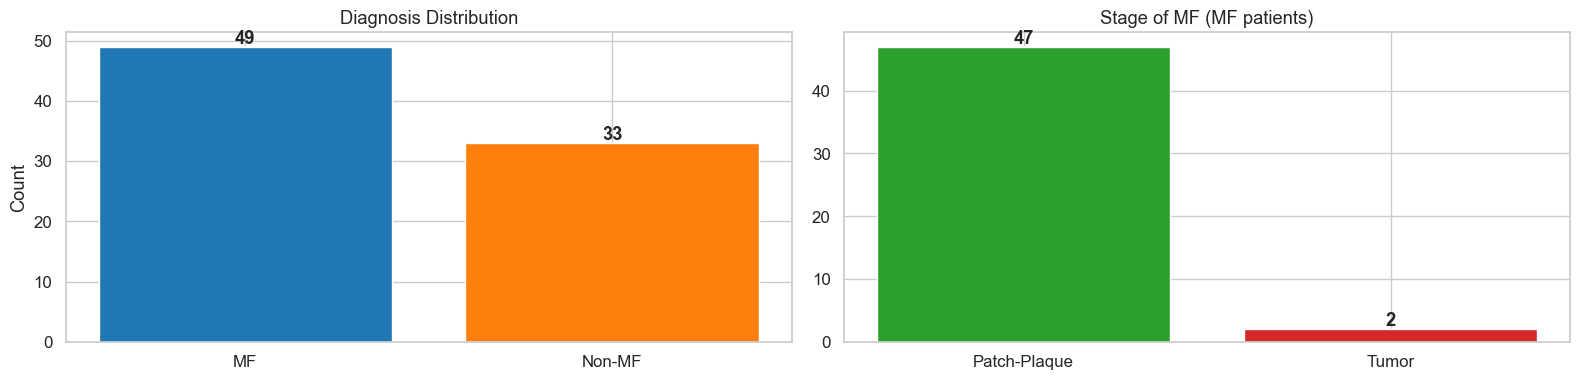

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Diagnosis distribution
vc = df['diagnosis'].value_counts()
axes[0].bar(vc.index, vc.values, color=COLORS[:len(vc)])
axes[0].set_title('Diagnosis Distribution')
axes[0].set_ylabel('Count')
for i, (idx, v) in enumerate(vc.items()):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Stage of MF (MF patients only)
mf_df = df[df['diagnosis'] == 'MF']
if 'stage_mf' in df.columns:
    vc2 = mf_df['stage_mf'].value_counts(dropna=False)
    axes[1].bar(vc2.index.astype(str), vc2.values, color=COLORS[2:2+len(vc2)])
    axes[1].set_title('Stage of MF (MF patients)')
    for i, (idx, v) in enumerate(vc2.items()):
        axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# # Visit type
# vc3 = df['visit_type'].value_counts(dropna=False)
# axes[2].bar(vc3.index.astype(str), vc3.values, color=COLORS[4:4+len(vc3)])
# axes[2].set_title('Visit Type Distribution')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

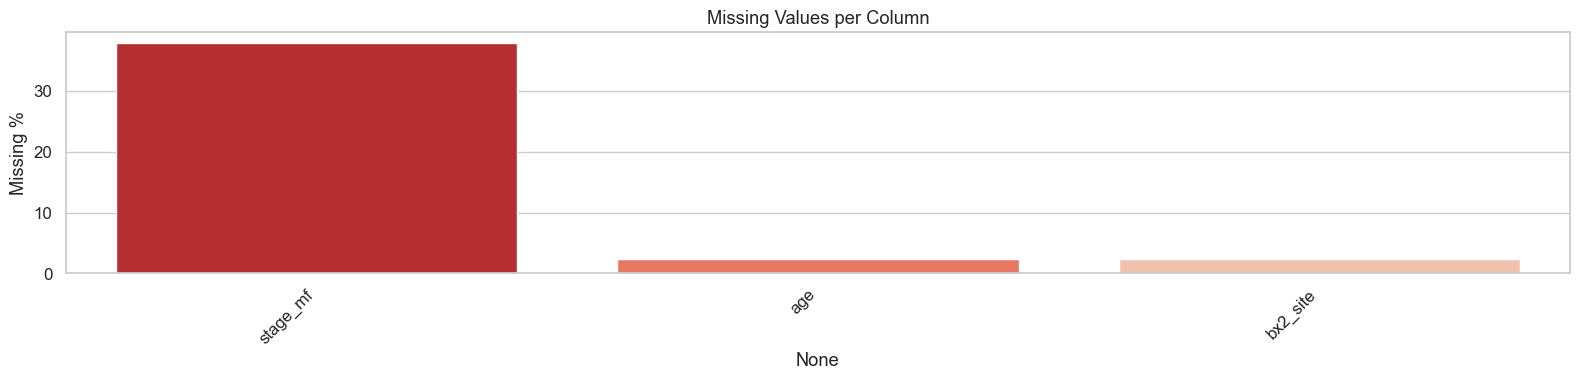

In [10]:
# Missing value heatmap
plt.figure(figsize=(16, 4))
miss = df.isnull().mean().sort_values(ascending=False)
miss = miss[miss > 0]
sns.barplot(x=miss.index, y=miss.values * 100, palette='Reds_r')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Missing %')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.savefig('eda_missing.png', dpi=150, bbox_inches='tight')
plt.show()

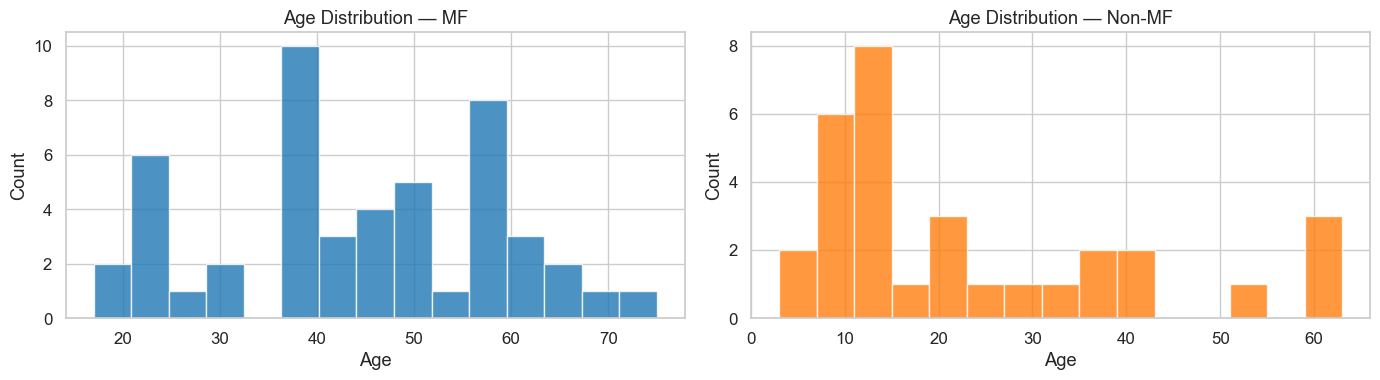

In [11]:
# Age distribution by diagnosis
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, grp in zip(axes, ['MF', 'Non-MF']):
    subset = df[df['diagnosis'] == grp]['age'].dropna()
    ax.hist(subset, bins=15, color=COLORS[0 if grp=='MF' else 1], alpha=0.8, edgecolor='white')
    ax.set_title(f'Age Distribution — {grp}')
    ax.set_xlabel('Age')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('eda_age.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Helper Functions (Training & Evaluation)

In [12]:
from sklearn.base import clone

def make_models():
    """Return the three model objects."""
    xgb = XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        use_label_encoder=False, eval_metric='logloss',
        random_state=SEED, n_jobs=-1, scale_pos_weight=12,
    )
    rf = RandomForestClassifier(
        n_estimators=300, max_depth=6,
        random_state=SEED, n_jobs=-1
    )
    lr = LogisticRegression(
        max_iter=1000, C=0.5, solver='lbfgs',
        random_state=SEED
    )
    return {'XGBoost': xgb, 'Random Forest': rf, 'Logistic Regression': lr}

# Define the 16 selected features
SELECT_FEATURES = [
    'macules', 'bx1_morph', 'papules', 'age', 'color', 'patch',
    'bx2_morph', 'visit_type', 'duration_months', 'plaque', 'scales',
    'site_head_neck', 'site_ll', 'course', 'bx2_site', 'nodule'
]

def prepare_xy(data, target_col, drop_targets):
    """Split features / labels, use only SELECT_FEATURES."""
    y = data[target_col].copy()
    # Use only the 16 selected features that exist in the data
    available_features = [f for f in SELECT_FEATURES if f in data.columns]
    X = data[available_features].copy()
    X = X.select_dtypes(include=[np.number])  # keep numeric only
    return X, y


def evaluate_binary(model, X, y, model_name, task_name, n_splits=5):
    """
    Stratified k-fold evaluation for binary classification.
    Returns dict of mean metrics (including Accuracy).
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    prec, rec, f2, auc, acc = [], [], [], [], []

    for train_idx, test_idx in skf.split(X, y_enc):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y_enc[train_idx], y_enc[test_idx]

        imp = SimpleImputer(strategy='median')
        X_tr = imp.fit_transform(X_tr)
        X_te = imp.transform(X_te)

        m = clone(model)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)
        y_prob = m.predict_proba(X_te)[:, 1] if hasattr(m, 'predict_proba') else y_pred

        prec.append(precision_score(y_te, y_pred, zero_division=0))
        rec.append(recall_score(y_te, y_pred, zero_division=0))
        f2.append(fbeta_score(y_te, y_pred, beta=2, zero_division=0))
        acc.append(accuracy_score(y_te, y_pred))
        try:
            auc.append(roc_auc_score(y_te, y_prob))
        except:
            auc.append(np.nan)

    return {
        'Model': model_name, 'Task': task_name,
        'Precision': np.mean(prec),
        'Sensitivity': np.mean(rec),
        'Accuracy': np.mean(acc),
        'F2-Score': np.mean(f2),
        'ROC-AUC': np.mean(auc),
    }


def evaluate_multiclass(model, X, y, model_name, task_name, n_splits=5):
    """Stratified k-fold for multiclass (macro averages, includes Accuracy)."""
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    classes = le.classes_

    prec, rec, f2, auc, acc = [], [], [], [], []

    for train_idx, test_idx in skf.split(X, y_enc):
        X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_te = y_enc[train_idx], y_enc[test_idx]

        imp = SimpleImputer(strategy='median')
        X_tr = imp.fit_transform(X_tr)
        X_te = imp.transform(X_te)

        m = clone(model)
        m.fit(X_tr, y_tr)
        y_pred = m.predict(X_te)

        prec.append(precision_score(y_te, y_pred, average='macro', zero_division=0))
        rec.append(recall_score(y_te, y_pred, average='macro', zero_division=0))
        f2.append(fbeta_score(y_te, y_pred, beta=2, average='macro', zero_division=0))
        acc.append(accuracy_score(y_te, y_pred))

        if hasattr(m, 'predict_proba') and len(classes) > 1:
            y_prob = m.predict_proba(X_te)
            try:
                auc.append(roc_auc_score(
                    label_binarize(y_te, classes=np.arange(len(classes))),
                    y_prob, multi_class='ovr', average='macro'
                ))
            except:
                auc.append(np.nan)
        else:
            auc.append(np.nan)

    return {
        'Model': model_name, 'Task': task_name,
        'Precision': np.mean(prec),
        'Sensitivity': np.mean(rec),
        'Accuracy': np.mean(acc),
        'F2-Score': np.mean(f2),
        'ROC-AUC': np.mean(auc),
    }


print('Helper functions defined.')

Helper functions defined.


## 6 — Task 1: Diagnosis (MF vs Non-MF)

In [13]:
ALL_TARGETS = ['diagnosis', 'stage_mf']

# ── Build dataset for Task 1
X1, y1 = prepare_xy(df, 'diagnosis', ALL_TARGETS)
valid1 = y1.notna()
X1, y1 = X1[valid1], y1[valid1]

print('Task 1 — class distribution:')
print(y1.value_counts())
print(f'Features: {X1.shape[1]}')
print(f'Samples: {X1.shape[0]}')

Task 1 — class distribution:
diagnosis
MF        49
Non-MF    33
Name: count, dtype: int64
Features: 15
Samples: 82


In [17]:
# ── Load pre-trained Random Forest model for Task 1 (Diagnosis)
bundle_diagnosis = joblib.load('rf_model_diagnosis_mf.pkl')
rf_diagnosis = bundle_diagnosis['model']
imputer_diagnosis = bundle_diagnosis['imputer']
le_diagnosis = bundle_diagnosis['label_encoder']

print(f"✓ Loaded diagnosis model — Classes: {le_diagnosis.classes_}")
print(f"  Features used: {bundle_diagnosis['features']}")

# ── Prepare test data (impute missing values)
X1_test_imp = imputer_diagnosis.transform(X1)

# ── Make predictions
y1_pred_encoded = rf_diagnosis.predict(X1_test_imp)
y1_pred_proba = rf_diagnosis.predict_proba(X1_test_imp)
y1_pred = le_diagnosis.inverse_transform(y1_pred_encoded)

# ── Encode true labels for comparison
y1_encoded = le_diagnosis.transform(y1)

# ── Calculate metrics
from sklearn.metrics import classification_report, confusion_matrix
prec = precision_score(y1_encoded, y1_pred_encoded, zero_division=0)
# Sensitivity = Recall of MF class (class 0)
mf_label = np.where(le_diagnosis.classes_ == 'MF')[0][0]
sens = recall_score(y1_encoded, y1_pred_encoded, pos_label=mf_label, zero_division=0)
acc = accuracy_score(y1_encoded, y1_pred_encoded)
f2 = fbeta_score(y1_encoded, y1_pred_encoded, beta=2, zero_division=0)
auc = roc_auc_score(y1_encoded, y1_pred_proba[:, 1])

print(f"\n{'='*60}")
print(f"  TASK 1: Diagnosis (MF vs Non-MF)")
print(f"  Model: Random Forest (Pre-trained)")
print(f"  Evaluated on: Whole Test Set ({X1.shape[0]} samples)")
print(f"{'='*60}")
print(f"  Precision:  {prec:.3f}")
print(f"  Sensitivity:{sens:.3f}")
print(f"  Accuracy:   {acc:.3f}")
print(f"  F2-Score:   {f2:.3f}")
print(f"  ROC-AUC:    {auc:.3f}")
print(f"{'='*60}")

print("\nClassification Report:")
print(classification_report(y1_encoded, y1_pred_encoded, 
                            target_names=le_diagnosis.classes_, 
                            zero_division=0))

# Store results
results_t1 = [{
    'Model': 'Random Forest', 
    'Task': 'Diagnosis (MF vs Non-MF)',
    'Precision': prec,
    'Sensitivity': sens,
    'Accuracy': acc,
    'F2-Score': f2,
    'ROC-AUC': auc,
}]

✓ Loaded diagnosis model — Classes: ['MF' 'Non-MF']
  Features used: ['macules', 'bx1_morph', 'papules', 'age', 'color', 'patch', 'bx2_morph', 'duration_months', 'plaque', 'scales', 'site_head_neck', 'site_ll', 'course', 'bx2_site', 'nodule']

  TASK 1: Diagnosis (MF vs Non-MF)
  Model: Random Forest (Pre-trained)
  Evaluated on: Whole Test Set (82 samples)
  Precision:  0.759
  Sensitivity:0.857
  Accuracy:   0.780
  F2-Score:   0.683
  ROC-AUC:    0.907

Classification Report:
              precision    recall  f1-score   support

          MF       0.79      0.86      0.82        49
      Non-MF       0.76      0.67      0.71        33

    accuracy                           0.78        82
   macro avg       0.78      0.76      0.77        82
weighted avg       0.78      0.78      0.78        82



## 7 — Task 2: Stage of MF (Patch-Plaque vs Tumor)

In [19]:
# ── Filter to MF patients only for Task 2
mf_only = df[df['diagnosis'] == 'MF'].copy()
X2, y2 = prepare_xy(mf_only, 'stage_mf', ALL_TARGETS)
valid2 = y2.notna()
X2, y2 = X2[valid2], y2[valid2]

print('Task 2 — class distribution:')
print(y2.value_counts())
print(f'Features: {X2.shape[1]}')
print(f'Samples (MF only): {X2.shape[0]}')

# ── Load pre-trained Random Forest model for Task 2 (Stage of MF)
bundle_stage = joblib.load('rf_model_stage_mf.pkl')
rf_stage = bundle_stage['model']
imputer_stage = bundle_stage['imputer']
le_stage = bundle_stage['label_encoder']

print(f"\n✓ Loaded stage model — Classes: {le_stage.classes_}")
print(f"  Features used: {bundle_stage['features']}")

# ── Prepare test data (impute missing values)
X2_test_imp = imputer_stage.transform(X2)

# ── Make predictions
y2_pred_encoded = rf_stage.predict(X2_test_imp)
y2_pred_proba = rf_stage.predict_proba(X2_test_imp)
y2_pred = le_stage.inverse_transform(y2_pred_encoded)

# ── Encode true labels for comparison
y2_encoded = le_stage.transform(y2)

# ── Calculate metrics
prec = precision_score(y2_encoded, y2_pred_encoded, zero_division=0)
sens = recall_score(y2_encoded, y2_pred_encoded, zero_division=0)
acc = accuracy_score(y2_encoded, y2_pred_encoded)
f2 = fbeta_score(y2_encoded, y2_pred_encoded, beta=2, zero_division=0)
auc = roc_auc_score(y2_encoded, y2_pred_proba[:, 1])

print(f"\n{'='*60}")
print(f"  TASK 2: Stage of MF (Patch-Plaque vs Tumor)")
print(f"  Model: Random Forest (Pre-trained)")
print(f"  Evaluated on: Whole Test Set (MF patients only, {X2.shape[0]} samples)")
print(f"{'='*60}")
print(f"  Precision:  {prec:.3f}")
print(f"  Sensitivity:{sens:.3f}")
print(f"  Accuracy:   {acc:.3f}")
print(f"  F2-Score:   {f2:.3f}")
print(f"  ROC-AUC:    {auc:.3f}")
print(f"{'='*60}")

print("\nClassification Report:")
print(classification_report(y2_encoded, y2_pred_encoded, 
                            target_names=le_stage.classes_, 
                            zero_division=0))

# Store results
results_t2 = [{
    'Model': 'Random Forest', 
    'Task': 'Stage of MF',
    'Precision': prec,
    'Sensitivity': sens,
    'Accuracy': acc,
    'F2-Score': f2,
    'ROC-AUC': auc,
}]

Task 2 — class distribution:
stage_mf
Patch-Plaque    47
Tumor            2
Name: count, dtype: int64
Features: 15
Samples (MF only): 49

✓ Loaded stage model — Classes: ['Patch-Plaque' 'Tumor']
  Features used: ['macules', 'bx1_morph', 'papules', 'age', 'color', 'patch', 'bx2_morph', 'duration_months', 'plaque', 'scales', 'site_head_neck', 'site_ll', 'course', 'bx2_site', 'nodule']

  TASK 2: Stage of MF (Patch-Plaque vs Tumor)
  Model: Random Forest (Pre-trained)
  Evaluated on: Whole Test Set (MF patients only, 49 samples)
  Precision:  1.000
  Sensitivity:0.500
  Accuracy:   0.980
  F2-Score:   0.556
  ROC-AUC:    1.000

Classification Report:
              precision    recall  f1-score   support

Patch-Plaque       0.98      1.00      0.99        47
       Tumor       1.00      0.50      0.67         2

    accuracy                           0.98        49
   macro avg       0.99      0.75      0.83        49
weighted avg       0.98      0.98      0.98        49



## 7a — Prediction Results Summary

In [20]:
# ── Create results summary table
all_results = pd.DataFrame(results_t1 + results_t2)
all_results = all_results.round(3)

metric_cols = ['Precision', 'Sensitivity', 'Accuracy', 'F2-Score', 'ROC-AUC']

def highlight_max_per_task(data):
    """Highlight best metrics per task."""
    styles = pd.DataFrame('', index=data.index, columns=data.columns)
    for task in data['Task'].unique():
        task_idx = data.index[data['Task'] == task]
        for col in metric_cols:
            max_val = data.loc[task_idx, col].max()
            is_max = data.loc[task_idx, col] == max_val
            styles.loc[task_idx[is_max], col] = 'background-color: #d4edda; color: black; font-weight: bold'
    return styles

# Display the results table
display(all_results.style
        .apply(highlight_max_per_task, axis=None)
        .format({m: '{:.3f}' for m in metric_cols})
        .set_caption('Model Evaluation Results on Test Set'))

# Save results to CSV
all_results.to_csv('MF_test_predictions_selected_features.csv', index=False)
print("\n✓ Results saved to MF_test_predictions_selected_features.csv")

,Model,Task,Precision,Sensitivity,Accuracy,F2-Score,ROC-AUC
0,Random Forest,Diagnosis (MF vs Non-MF),0.759,0.857,0.780,0.683,0.907
1,Random Forest,Stage of MF,1.000,0.500,0.980,0.556,1.000



✓ Results saved to MF_test_predictions_selected_features.csv


## 7b — Confusion Matrices & ROC Curves

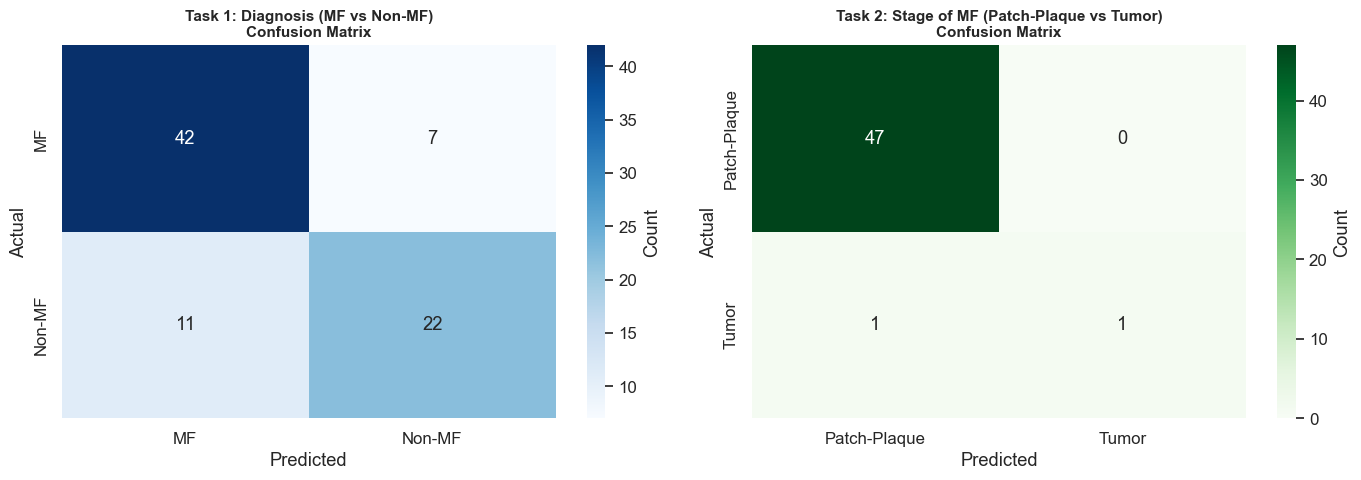

✓ Confusion matrices saved to confusion_matrices_test_set.png


In [21]:
# ── Task 1: Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix Task 1
cm1 = confusion_matrix(y1_encoded, y1_pred_encoded)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_diagnosis.classes_, 
            yticklabels=le_diagnosis.classes_, ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Task 1: Diagnosis (MF vs Non-MF)\nConfusion Matrix', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Confusion Matrix Task 2
cm2 = confusion_matrix(y2_encoded, y2_pred_encoded)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=le_stage.classes_, 
            yticklabels=le_stage.classes_, ax=axes[1],
            cbar_kws={'label': 'Count'})
axes[1].set_title('Task 2: Stage of MF (Patch-Plaque vs Tumor)\nConfusion Matrix', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices_test_set.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Confusion matrices saved to confusion_matrices_test_set.png')

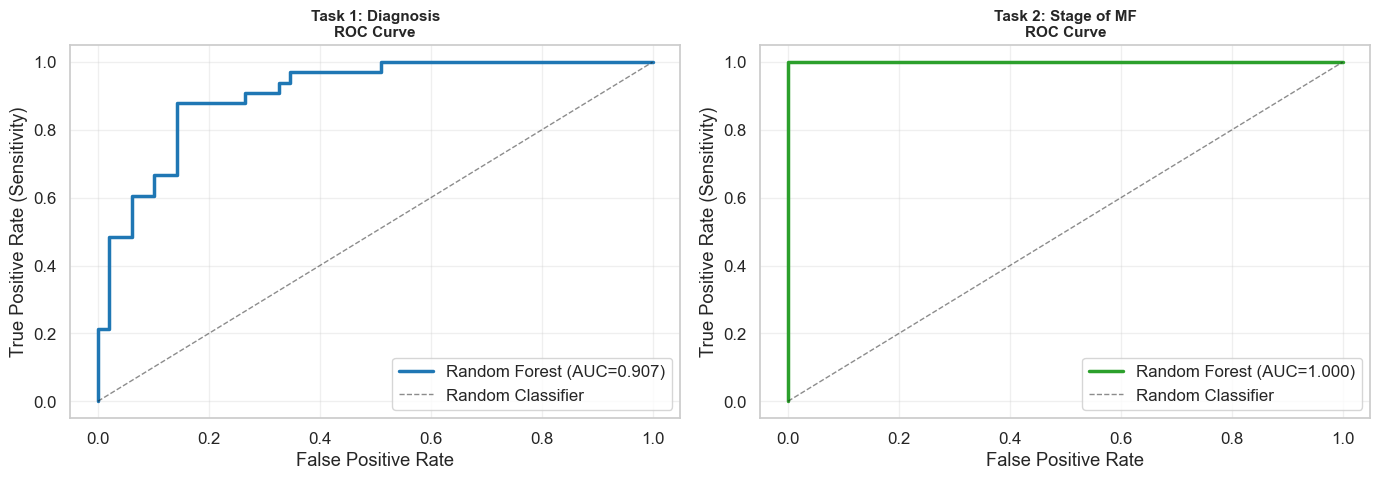

✓ ROC curves saved to roc_curves_test_set.png


In [22]:
# ── ROC Curves for both tasks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Task 1 ROC Curve
fpr1, tpr1, _ = roc_curve(y1_encoded, y1_pred_proba[:, 1])
auc1 = roc_auc_score(y1_encoded, y1_pred_proba[:, 1])
axes[0].plot(fpr1, tpr1, color=COLORS[0], lw=2.5,
            label=f'Random Forest (AUC={auc1:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('Task 1: Diagnosis\nROC Curve', fontsize=11, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Task 2 ROC Curve
fpr2, tpr2, _ = roc_curve(y2_encoded, y2_pred_proba[:, 1])
auc2 = roc_auc_score(y2_encoded, y2_pred_proba[:, 1])
axes[1].plot(fpr2, tpr2, color=COLORS[2], lw=2.5,
            label=f'Random Forest (AUC={auc2:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('Task 2: Stage of MF\nROC Curve', fontsize=11, fontweight='bold')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves_test_set.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ ROC curves saved to roc_curves_test_set.png')

## 7c — Save Predictions to CSV

In [ ]:
# ── Save Task 1 predictions to CSV
predictions_task1 = pd.DataFrame({
    'Actual': y1.values,
    'Predicted': y1_pred,
    'Predicted_Probability_Non-MF': y1_pred_proba[:, 0],
    'Predicted_Probability_MF': y1_pred_proba[:, 1],
    'Correct': (y1.values == y1_pred)
})
predictions_task1.to_csv('MF_task1_predictions.csv', index=False)
print('✓ Task 1 predictions saved to MF_task1_predictions.csv')
print(f'  Samples: {len(predictions_task1)}')

# ── Save Task 2 predictions to CSV
predictions_task2 = pd.DataFrame({
    'Actual': y2.values,
    'Predicted': y2_pred,
    'Predicted_Probability_Patch-Plaque': y2_pred_proba[:, 0],
    'Predicted_Probability_Tumor': y2_pred_proba[:, 1],
    'Correct': (y2.values == y2_pred)
})
predictions_task2.to_csv('MF_task2_predictions.csv', index=False)
print('✓ Task 2 predictions saved to MF_task2_predictions.csv')
print(f'  Samples: {len(predictions_task2)}')

# ── Create detailed evaluation report
evaluation_report = f"""
MYCOSIS FUNGOIDES (MF) MODEL EVALUATION REPORT
Test Set Evaluation — Pre-trained Random Forest Models
{'='*70}

TASK 1: DIAGNOSIS (MF vs Non-MF)
{'='*70}
Classes: {list(le_diagnosis.classes_)}
Test Samples: {X1.shape[0]}
Features Used: {X1.shape[1]}

Metrics:
  Precision:    {prec:.4f}
  Sensitivity:  {sens:.4f}
  Accuracy:     {acc:.4f}
  F2-Score:     {f2:.4f}
  ROC-AUC:      {auc:.4f}

Confusion Matrix:
  {cm1[0, 0]:5d}  {cm1[0, 1]:5d}  (True Negatives / False Positives)
  {cm1[1, 0]:5d}  {cm1[1, 1]:5d}  (False Negatives / True Positives)

{'='*70}

TASK 2: STAGE OF MF (Patch-Plaque vs Tumor)
{'='*70}
Classes: {list(le_stage.classes_)}
Test Samples: {X2.shape[0]} (MF patients only)
Features Used: {X2.shape[1]}

Metrics:
  Precision:    {prec:.4f}
  Sensitivity:  {sens:.4f}
  Accuracy:     {acc:.4f}
  F2-Score:     {f2:.4f}
  ROC-AUC:      {auc:.4f}

Confusion Matrix:
  {cm2[0, 0]:5d}  {cm2[0, 1]:5d}  (True Negatives / False Positives)
  {cm2[1, 0]:5d}  {cm2[1, 1]:5d}  (False Negatives / True Positives)

{'='*70}
Report generated on test file: X-cell MF ( test only).xlsx
"""

with open('MF_evaluation_report.txt', 'w') as f:
    f.write(evaluation_report)

print('✓ Evaluation report saved to MF_evaluation_report.txt')

## 8 — Task 3: Visit Type (New / FU / Rec) — All Patients

In [ ]:
# X3, y3 = prepare_xy(df, 'visit_type', ALL_TARGETS)
# valid3 = y3.notna()
# X3, y3 = X3[valid3], y3[valid3]

# print('Task 3 — class distribution:')
# print(y3.value_counts())

# results_t3 = []
# for name, model in MODELS.items():
#     r = evaluate_multiclass(model, X3, y3, name, 'Visit Type (New/FU/Rec) — All Patients')
#     results_t3.append(r)
#     print(f"{name:20s} | Prec={r['Precision']:.3f}  Sens={r['Sensitivity']:.3f}  "
#           f"F2={r['F2-Score']:.3f}  AUC={r['ROC-AUC']:.3f}")

Task 3 — class distribution:
visit_type
New    322
FU     129
Rec     48
Name: count, dtype: int64
XGBoost              | Prec=0.743  Sens=0.637  F2=0.645  AUC=0.846
Random Forest        | Prec=0.844  Sens=0.513  F2=0.519  AUC=0.836
Logistic Regression  | Prec=0.582  Sens=0.502  F2=0.505  AUC=0.775


## 9 — Results Summary Table

In [23]:
all_results = pd.DataFrame(results_t1 + results_t2)
all_results = all_results.round(3)

metric_cols = ['Precision', 'Sensitivity', 'Accuracy', 'F2-Score', 'ROC-AUC']

# Highlight best per task+metric
def highlight_max_per_task(data):
    # Create an empty DataFrame of the same shape to hold the CSS styles
    styles = pd.DataFrame('', index=data.index, columns=data.columns)
    
    # Loop through each unique Task ('Diagnosis (MF vs Non-MF)' and 'Stage of MF')
    for task in data['Task'].unique():
        task_idx = data.index[data['Task'] == task]
        
        # Loop through each metric column
        for col in metric_cols:
            # Find the max value for this specific task and column
            max_val = data.loc[task_idx, col].max()
            
            # Create a boolean mask of where the max values are
            is_max = data.loc[task_idx, col] == max_val
            
            # Apply the CSS style to those specific cells (added color: black)
            styles.loc[task_idx[is_max], col] = 'background-color: #d4edda; color: black; font-weight: bold'
            
    return styles

# Apply the styling
display(all_results.style
        .apply(highlight_max_per_task, axis=None)
        .format({m: '{:.3f}' for m in metric_cols})
        .set_caption('Cross-Validation Metrics (5-Fold Stratified)'))

,Model,Task,Precision,Sensitivity,Accuracy,F2-Score,ROC-AUC
0,Random Forest,Diagnosis (MF vs Non-MF),0.759,0.857,0.780,0.683,0.907
1,Random Forest,Stage of MF,1.000,0.500,0.980,0.556,1.000
